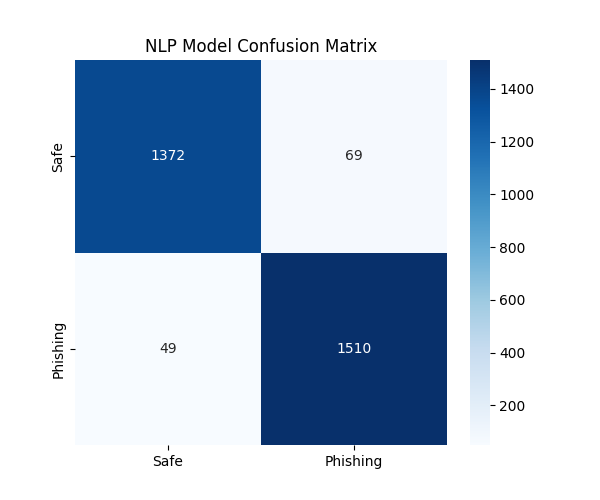

In [5]:
from IPython.display import Image, display

display(Image(filename='../results_nlp/nlp_confusion_matrix.png'))

In [ ]:
import torch
import re
from transformers import BertTokenizer, BertForSequenceClassification

def clean_text(text):
    text = str(text).lower()
    urls = len(re.findall(r'https?://[^\s<>"]+|www\.[^\s<>"]+', text))
    return f"[urls:{urls}] {text}"

# Look one folder up, then into the models folder
model_path = "../models/nlp_model_bert"
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)

raw_email = "URGENT: Your Netflix subscription has expired. Update your payment at http://login-netflix-secure.com immediately!"
processed_email = clean_text(raw_email)

inputs = tokenizer(processed_email, return_tensors="pt", truncation=True, max_length=256, padding=True)

with torch.no_grad():
    logits = model(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    prediction = torch.argmax(logits, dim=1).item()
    confidence = probs[0][prediction].item()

print(f"Processed Text: {processed_email}")
print(f"Result: {'🚨 PHISHING' if prediction == 1 else '✅ SAFE'}")
print(f"Confidence: {confidence*100:.2f}%")

Loading weights: 100%|██████████| 41/41 [00:00<00:00, 10249.52it/s]

Processed Text: [urls:1] urgent: your netflix subscription has expired. update your payment at http://login-netflix-secure.com immediately!
Result: 🚨 PHISHING
Confidence: 98.18%
